In [12]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import os
import sys

module_path = os.path.abspath('..')
if module_path not in sys.path:
    sys.path.insert(0, module_path)

from fit_param import SurrogateFitter
from sim import simulate_jaynes_cummings
from utils import load_config

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import os
import sys

module_path = os.path.abspath('..')
if module_path not in sys.path:
    sys.path.insert(0, module_path)

from fit_param import SurrogateFitter
from sim import simulate_jaynes_cummings
from utils import load_config

In [2]:
# 1. Generate a "secret" target curve using QuTiP (simulating experimental data)
config = load_config(os.path.join(module_path, "config.yaml"))
phys = config['physics']
true_g, true_kappa, true_gamma = 0.32, 0.04, 0.03  # Secret parameters

tlist, target_pe, _, _ = simulate_jaynes_cummings(
    wc=phys['cavity_freq'], wa=phys['atom_freq'], 
    g=true_g, kappa=true_kappa, gamma=true_gamma, 
    t_max=phys['t_max']
)

In [3]:
# Add a bit of experimental noise
target_pe += np.random.normal(0, 0.01, size=len(target_pe))

In [4]:
# 2. Initialize the Fitter
model_path = os.path.join(module_path, "checkpoints", "surrogate_final.pth")

# Initialize the fitter with the explicit path
fitter = SurrogateFitter(model_path=model_path, device="cpu")

Loading pre-trained surrogate model from /Users/samuelnoger/Programms/Jaynes-Cummings System/checkpoints/surrogate_final.pth...


In [9]:
import numpy as np

# Generate random initial guesses within plausible physical ranges for g, kappa, and gamma
params_init = {
    'g': np.random.uniform(0.1, 0.5),
    'kappa': np.random.uniform(0.01, 0.1),
    'gamma': np.random.uniform(0.01, 0.1)
}

print(f"Random initial guess: g={params_init['g']:.4f}, kappa={params_init['kappa']:.4f}, gamma={params_init['gamma']:.4f}")

# Pass it straight into the fitter
result = fitter.fit(tlist, params_init, target_pe, lr=0.01, steps=1000)

Random initial guess: g=0.2314, kappa=0.0714, gamma=0.0625
Starting parameter optimization...
Step 1/1000 | Loss: 0.06114 | g: 0.2314, kappa: 0.0714, gamma: 0.0625
Step 100/1000 | Loss: 0.00016 | g: 0.3198, kappa: 0.0310, gamma: 0.0403
Step 200/1000 | Loss: 0.00014 | g: 0.3193, kappa: 0.0308, gamma: 0.0394
Step 300/1000 | Loss: 0.00014 | g: 0.3194, kappa: 0.0311, gamma: 0.0390
Step 400/1000 | Loss: 0.00014 | g: 0.3194, kappa: 0.0315, gamma: 0.0387
Step 500/1000 | Loss: 0.00014 | g: 0.3194, kappa: 0.0317, gamma: 0.0384
Step 600/1000 | Loss: 0.00014 | g: 0.3194, kappa: 0.0320, gamma: 0.0382
Step 700/1000 | Loss: 0.00014 | g: 0.3194, kappa: 0.0322, gamma: 0.0380
Step 800/1000 | Loss: 0.00014 | g: 0.3194, kappa: 0.0323, gamma: 0.0379
Step 900/1000 | Loss: 0.00014 | g: 0.3195, kappa: 0.0323, gamma: 0.0379
Step 1000/1000 | Loss: 0.00014 | g: 0.3195, kappa: 0.0323, gamma: 0.0379


In [10]:
print("\n--- Optimization Results ---")
print(f"True Parameters:    g={true_g}, kappa={true_kappa}, gamma={true_gamma}")
print(f"Recovered by Fit:   g={result['g']:.4f}, kappa={result['kappa']:.4f}, gamma={result['gamma']:.4f}")


--- Optimization Results ---
True Parameters:    g=0.32, kappa=0.04, gamma=0.03
Recovered by Fit:   g=0.3195, kappa=0.0323, gamma=0.0379


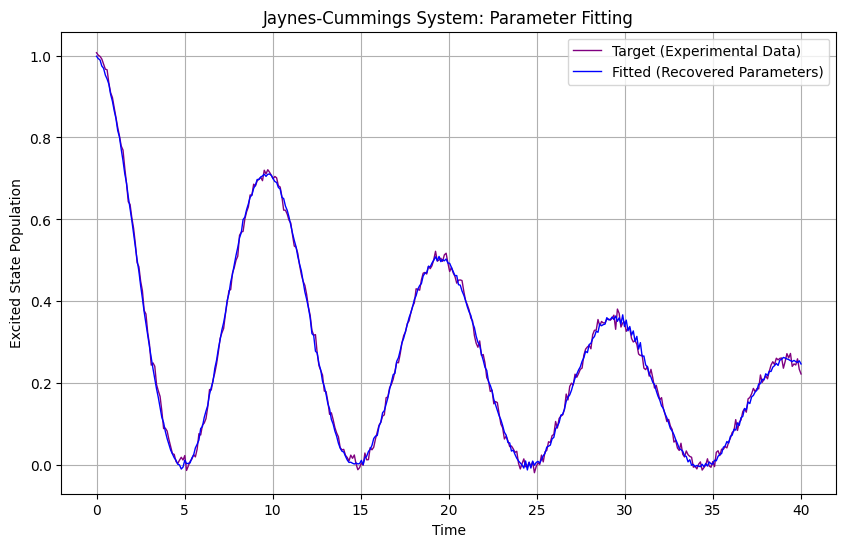

In [19]:
g_fit = result['g']
kappa_fit = result['kappa']
gamma_fit = result['gamma']

#  Generate the predicted curve using your surrogate model with the fitted parameters
# Create a tensor for the time steps and a batch tensor for the fitted parameters
t_tensor = torch.tensor(tlist, dtype=torch.float32, device=fitter.device).unsqueeze(1)
params_vector = torch.tensor([g_fit, kappa_fit, gamma_fit], dtype=torch.float32, device=fitter.device)
params_batch = params_vector.repeat(len(tlist), 1)

# Ensure the model is in eval mode and predict the fitted trajectory
fitter.model.eval()
with torch.no_grad():
    pe_fit_tensor = fitter.model(t_tensor, params_batch)
    pe_fit = pe_fit_tensor.squeeze().cpu().numpy()

# Set tlist_fit equal to your original time list
tlist_fit = tlist

#Plot the results

plt.figure(figsize=(10, 6))
plt.plot(tlist, target_pe, label='Target (Experimental Data)', color='purple', linewidth=1)
plt.plot(tlist_fit, pe_fit, label='Fitted (Recovered Parameters)', color='blue', linestyle='-', linewidth=1)
plt.xlabel('Time')
plt.ylabel('Excited State Population')
plt.title('Jaynes-Cummings System: Parameter Fitting')
plt.legend()
plt.grid()
plt.show()

